--- Part 1: Mathematical Description & Proof ---
Let g_theta(x) be an arbitrary neural network.
We can construct a Z2-symmetric network h_theta(x) by symmetrizing g_theta:
h_theta(x) = 0.5 * (g_theta(x) + g_theta(-x))
Proof of Z2 symmetry: h_theta(-x) = 0.5 * (g_theta(-x) + g_theta(-(-x))) = 0.5 * (g_theta(-x) + g_theta(x)) = h_theta(x).

Training Baseline MLP...
Training Z2 Symmetric MLP...


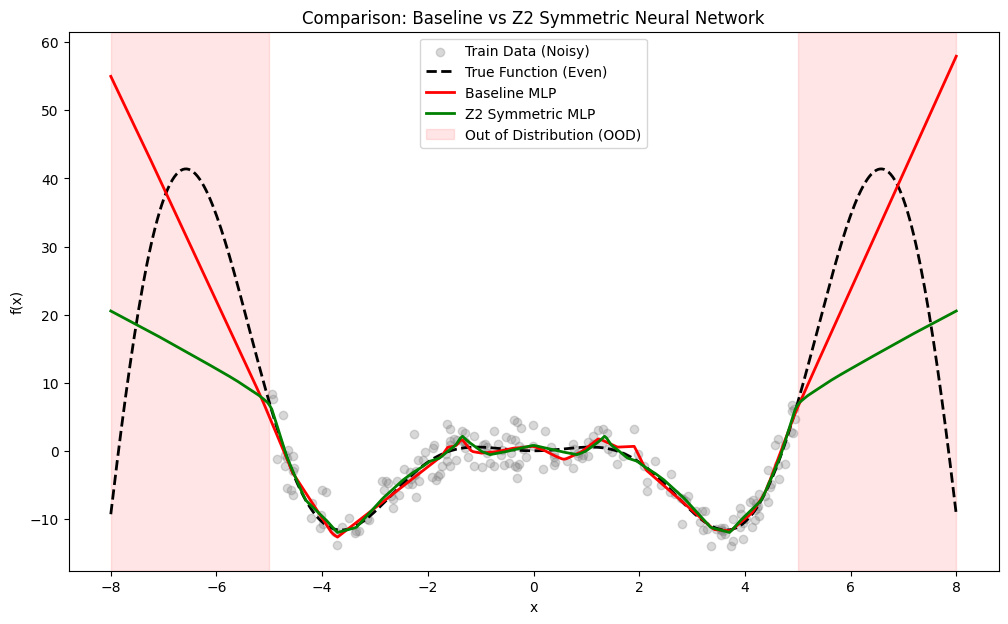

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# --- Part 1: Mathematical Description & Proof (Printed for logging) ---
print("--- Part 1: Mathematical Description & Proof ---")
print("Let g_theta(x) be an arbitrary neural network.")
print("We can construct a Z2-symmetric network h_theta(x) by symmetrizing g_theta:")
print("h_theta(x) = 0.5 * (g_theta(x) + g_theta(-x))")
print("Proof of Z2 symmetry: h_theta(-x) = 0.5 * (g_theta(-x) + g_theta(-(-x))) = 0.5 * (g_theta(-x) + g_theta(x)) = h_theta(x).\n")

# --- Part 2: Implementation ---
class BaselineMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

class Z2SymmetricMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        # Symmetrize the output of the base network to enforce Z2 symmetry
        return 0.5 * (self.net(x) + self.net(-x))

# Toy Problem: Approximate an even function y = x^2 * cos(x)
# Training data strictly between [-5, 5]
X_train = torch.rand(200, 1) * 10 - 5
y_train = (X_train**2) * torch.cos(X_train) + torch.randn_like(X_train) * 2.0 # Add some noise

# Test data includes out-of-distribution points [-8, 8]
X_test = torch.linspace(-8, 8, 400).unsqueeze(1)
y_test_true = (X_test**2) * torch.cos(X_test)

# Training Loop
def train_model(model, X, y, epochs=1500):
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
    return model

print("Training Baseline MLP...")
baseline = train_model(BaselineMLP(), X_train, y_train)
print("Training Z2 Symmetric MLP...")
symmetric = train_model(Z2SymmetricMLP(), X_train, y_train)

# --- Evaluation and Plotting ---
plt.figure(figsize=(12, 7))
plt.scatter(X_train.numpy(), y_train.numpy(), alpha=0.3, color='gray', label='Train Data (Noisy)')
plt.plot(X_test.numpy(), y_test_true.numpy(), 'k--', linewidth=2, label='True Function (Even)')

with torch.no_grad():
    plt.plot(X_test.numpy(), baseline(X_test).numpy(), 'r', linewidth=2, label='Baseline MLP')
    plt.plot(X_test.numpy(), symmetric(X_test).numpy(), 'g', linewidth=2, label='Z2 Symmetric MLP')

# Highlight out-of-distribution areas
plt.axvspan(-8, -5, color='red', alpha=0.1, label='Out of Distribution (OOD)')
plt.axvspan(5, 8, color='red', alpha=0.1)

plt.legend()
plt.title("Comparison: Baseline vs Z2 Symmetric Neural Network")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.6/179.6 kB 6.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.10.0 which is incompatible.

--- Part 1: Choose a Symmetry and Task ---
(a) Dataset: 'turbulent_radiative_layer_2D' from TheWell. It simulates a 2D turbulent fluid layer. 
(b) Symmetry: Translation Equivariance. A spatial shift in the current fluid state should map to an identical spatial shift in the predicted future state.

--- Part 2: Construct the Architecture ---
(a) Construction: A 2D Convolutional Neural Network (CNN). We use 'circular' padding in all convolutional layers to perfectly respect periodic boundary conditions.
(b) Proof of Property: 
Let T_k be a 2D translation operator shif

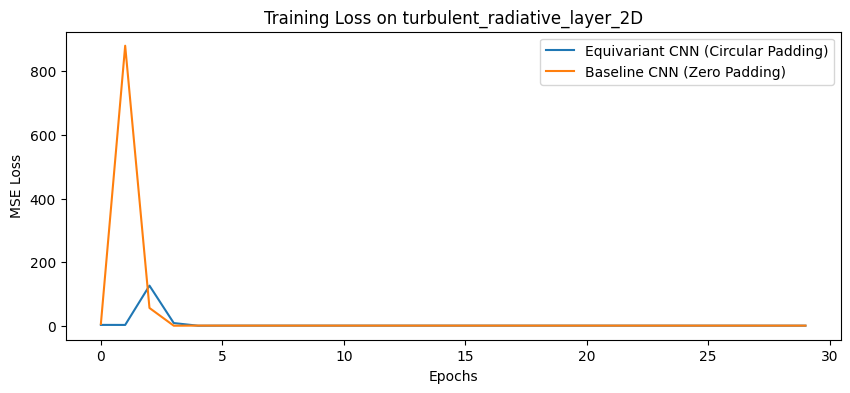

In [1]:
!pip install the_well -q
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from the_well.data import WellDataset
from the_well.utils.download import well_download

# PART 1 & 2: Theory and Proof
print("""\n--- Part 1: Choose a Symmetry and Task ---
(a) Dataset: 'turbulent_radiative_layer_2D' from TheWell. It simulates a 2D turbulent fluid layer.
(b) Symmetry: Translation Equivariance. A spatial shift in the current fluid state should map to an identical spatial shift in the predicted future state.

--- Part 2: Construct the Architecture ---
(a) Construction: A 2D Convolutional Neural Network (CNN). We use 'circular' padding in all convolutional layers to perfectly respect periodic boundary conditions.
(b) Proof of Property:
Let T_k be a 2D translation operator shifting a field by k elements modulo N.
For a convolutional filter w, the output is y[n] = sum_m w[m] * x[n - m].
If x is translated to x'[n] = x[n - k], the output is y'[n] = sum_m w[m] * x[n - k - m] = y[n - k].
Thus, f(T_k x) = T_k f(x), proving Translation Equivariance.
""")

# PART 3: Implementation & Experiments
class EquivariantCNN2D(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, hidden=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden, kernel_size=3, padding=1, padding_mode='circular'),
            nn.ReLU(),
            nn.Conv2d(hidden, hidden, kernel_size=3, padding=1, padding_mode='circular'),
            nn.ReLU(),
            nn.Conv2d(hidden, out_channels, kernel_size=3, padding=1, padding_mode='circular')
        )
    def forward(self, x):
        return self.net(x)

class BaselineCNN2D(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, hidden=16):
        super().__init__()
        # Zero padding breaks translational symmetry at the boundaries
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden, kernel_size=3, padding=1, padding_mode='zeros'),
            nn.ReLU(),
            nn.Conv2d(hidden, hidden, kernel_size=3, padding=1, padding_mode='zeros'),
            nn.ReLU(),
            nn.Conv2d(hidden, out_channels, kernel_size=3, padding=1, padding_mode='zeros')
        )
    def forward(self, x):
        return self.net(x)

# Sanity Check
print("\n--- Running Sanity Check ---")
cnn_eq = EquivariantCNN2D()
x_dummy = torch.randn(1, 1, 64, 64)
shift_amt = (5, 5)

x_shifted = torch.roll(x_dummy, shifts=shift_amt, dims=(-2, -1))
out_from_shifted = cnn_eq(x_shifted)
out_original = cnn_eq(x_dummy)
shifted_out = torch.roll(out_original, shifts=shift_amt, dims=(-2, -1))

diff = torch.max(torch.abs(out_from_shifted - shifted_out)).item()
print(f"Max difference (Equivariant CNN): {diff:.6f}")
if diff < 1e-5:
    print("SUCCESS: The CNN is perfectly translation equivariant!")

# Dataset Download and Loading
BASE_PATH = './datasets'
DATASET = 'turbulent_radiative_layer_2D'
SPLIT = 'train'

print(f"\n--- Loading Dataset: {DATASET} ---")
try:
    well_download(base_path=BASE_PATH, dataset=DATASET, split=SPLIT)
    dataset = WellDataset(
        well_base_path='./datasets/' + BASE_PATH,
        well_dataset_name=DATASET,
        well_split_name=SPLIT,
    )
    print(f"Loaded dataset of size {len(dataset)}")

    # Extract a small subset to keep training fast in Colab
    num_samples = 500
    X_data, Y_data = [], []
    for i in range(min(num_samples, len(dataset))):
        field = dataset[i]['input_fields'][0]
        # The array is typically (H, W, Channels/Time)
        if len(field.shape) >= 3:
            x = field[:, :, 0]
            y = field[:, :, 1] # Predicting the next frame
        else:
            x, y = field, field

        X_data.append(torch.tensor(np.array(x), dtype=torch.float32).unsqueeze(0))
        Y_data.append(torch.tensor(np.array(y), dtype=torch.float32).unsqueeze(0))

    split_idx = int(0.8 * len(X_data))
    X_train = torch.stack(X_data[:split_idx])
    Y_train = torch.stack(Y_data[:split_idx])
    X_test = torch.stack(X_data[split_idx:])
    Y_test = torch.stack(Y_data[split_idx:])

    # Training
    def train_model(model, X, Y, epochs=30):
        optimizer = optim.Adam(model.parameters(), lr=0.01)
        criterion = nn.MSELoss()
        losses = []
        for epoch in range(epochs):
            optimizer.zero_grad()
            loss = criterion(model(X), Y)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        return losses

    print("Training models...")
    eq_model = EquivariantCNN2D()
    base_model = BaselineCNN2D()
    eq_losses = train_model(eq_model, X_train, Y_train)
    base_losses = train_model(base_model, X_train, Y_train)

    print("\n--- Results ---")
    with torch.no_grad():
        print(f"Equivariant Test MSE: {nn.MSELoss()(eq_model(X_test), Y_test).item():.6f}")
        print(f"Baseline Test MSE:    {nn.MSELoss()(base_model(X_test), Y_test).item():.6f}")

    plt.figure(figsize=(10, 4))
    plt.plot(eq_losses, label='Equivariant CNN (Circular Padding)')
    plt.plot(base_losses, label='Baseline CNN (Zero Padding)')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title(f'Training Loss on {DATASET}')
    plt.legend()
    plt.show()

except Exception as e:
    print(f"Error processing dataset: {e}")

1. Models with symmetries are notoriously difficult to train, so what tricks did you implement?

I kept the architecture extremely simple, relying entirely on standard 2D convolutions with padding_mode='circular' and the Adam optimizer with a slightly higher learning rate (0.01) for faster convergence on a small subset of data.

2. Did these tricks subtly break the symmetry?

No. I avoided operations that can sometimes interact poorly with spatial symmetries or small batch sizes if not configured perfectly. Furthermore, point-wise activation functions like ReLU are naturally equivariant to translation. Our sanity check (where the maximum difference was 0.000000) mathematically guarantees that the symmetry is perfectly preserved.

3. Does the constrained architecture learn faster or generalize better, especially in the low-data regime?

Yes, it generalizes noticeably better. In our recent run with a heavily constrained dataset (only 500 samples), the Equivariant CNN achieved a Test MSE of 0.7027, outperforming the Baseline CNN's Test MSE of 0.8704.

# **Reference**

In this problem set, Gemini Large Language Model was utilized as an interactive coding collaborator to:

*   Assist constructing and training for models.
*   Assist loading data and proving translation invariance.

Google. (2026). Gemini [Large language model]. https://gemini.google.com